Multi-Class Classification of cyber attacks on UNSW-NB15 dataset  
Code Written by Cliff Pham

First we can visualize the dataset we are working with, so we know what we should do in the pre-processing stage, one of the most important stages in our framework to solve this multi-class classification problem.


In [ ]:
# download dataset from kaggle. In my repository i will store the CSV files within the "dataset" folder.
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

In [1]:
import pandas as pd

testing = pd.read_csv("dataset/UNSW_NB15_training-set.csv")

training = pd.read_csv("dataset/UNSW_NB15_testing-set.csv")
print(f"training dimensions: {training.shape}\n testing dimensions: {testing.shape}")

training.head()

training dimensions: (175341, 45)
 testing dimensions: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [89]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [90]:
training.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


We can see that there are some categorical features. We can see which features are categorical and apply some encoding since models can only understand numerical values and not texts!

In [ ]:
# categorical_features = list(training.select_dtypes(include=['object']).columns)
# categorical_features.remove("attack_cat") # this is different since it is our multi-class label

# print(f"Categorical Features: {categorical_features}")


Categorical Features: ['proto', 'service', 'state']


In [71]:
training.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


It will be more convenient to apply all these pre-processing to both training and testing sets at once, hence I will merge them together and re-split them for model input and evaluation.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

training = training.drop(axis = 1, columns=['id'])
testing = testing.drop(axis = 1,columns = ['id'])
X_train, X_test = training.drop(axis = 1,columns=['attack_cat', 'label']), testing.drop(axis = 1,columns=['attack_cat', 'label'])
y_train, y_test = training['attack_cat'], testing['attack_cat']


categorical_features = list(training.select_dtypes(include=['object']).columns)
categorical_features.remove("attack_cat") # this is different since it is our multi-class label

print(f"Categorical Features: {categorical_features}")

for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')
    X_test[col] = X_test[col].cat.set_categories(X_train[col].cat.categories)

X_train_reduced, X_test_reduced = X_train, X_test

# num_cols = [col for col in X_train.columns if col not in categorical_features]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output = False), categorical_features),
#         ('num', 'passthrough', num_cols)
#     ]
# )

le = LabelEncoder()

# preprocessor.set_output(transform = "pandas")

# X_train_reduced = preprocessor.fit_transform(X_train)
# X_test_reduced = preprocessor.transform(X_test)

y_train_final = le.fit_transform(y_train)
y_test_final = le.transform(y_test)




Categorical Features: ['proto', 'service', 'state']


In [76]:
X_train_reduced.head()


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.000011,117,0,4,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0
1,0.000008,117,0,4,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0
2,0.000005,117,0,4,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0
3,0.000006,117,0,4,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0
4,0.000010,117,0,4,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0


In [77]:
print(y_train_final)

[6 6 6 ... 6 6 6]


Now we will visualize the type of attacks from the attack_cat label to see if there is any data imbalance

In [78]:
print(training['attack_cat'].value_counts())

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


We can see there is indeed data imbalance, as there are less network logs that are Worms attack, and we also see that Normal network logs makes a large majority of the dataset. We need to utilize data imbalance algorithms to handle this. However we should also do feature selection / dimensional reduction first before we tackle the case of data imbalance.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# X = df.drop(columns = ['label', 'attack_cat']) # we just want the features not including labels

# # encode the attack_cat label because its categorical
# le = LabelEncoder()
# df['attack_cat'] = le.fit_transform(df['attack_cat'])
# y = df['attack_cat'].values

# X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =12345678)




,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.000011,119,0,5,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0
1,0.000008,119,0,5,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0
2,0.000005,119,0,5,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0
3,0.000006,119,0,5,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0
4,0.000010,119,0,5,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0


Quick note: since we are utilizing tree-based models, they don't rely on distances so scaling is not necesarry, though its good practice.

When dealing with dimensional reductions, there are many algorithms we can utilize depending if our dataset can be linearly seperable or not. However there is another case we need to keep in mind - if the type of feature selection algorithm generates new features, will that feature make 'sense' with respect to our original dataset ? In this case PCA wouldn't be viable since PCA generates new features which could possibly not make sense to our original data, and same case with the SMOTE algorithm for tackling data imbalance which we will see later...  
  
So in this case, we would have to perform feature selection rather than dimensional reduction, we can do this by analyzing which features have high correleation with other existing features in our dataset, and we will remove them to ensure that there are no correlating features in our dataset. This allows for computational optimization, imrpovement in generalization and reducing the risk of our model overfitting to our dataset. The algorithm that we will use is the Random Forest algorithm, and this algorithm is chosen because it is a stable version of the algorithm that we will use as our classification model (XGBoost) and is less prone to overfitting. Random Forest will allow us to identify which features have the highest importance, allowing us to discard other irelevant features.  

There is one other thing to mention - RandomForest is only selecting the most important features with respect to our dataset. What if multiple features are correlated ? In that case RandomForest may keep or drop those correlated features which is an issue. To address this, we will determine which features have high correlations and discard them before we run feature importance via RandomForest. To do this, we will utilize a correlation matrix.

In [ ]:
# correlation_matrix = X_train_final.corr().abs()

# # we will select the upper triangle to avoid comparing the diagonal (self-comparisons) and the lower triangle because due to symetry
# # of the correlation matrix, we would find every pair twice and we would delete both features in the pair
# upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k = 1).astype(bool))

# features_to_drop = [column for column in upper.columns if any(upper[column] > 0.95)] # we set threshold where if > .95 correlation, feature will be dropped.

# print(f"Features to be dropped : {features_to_drop}")

# X_train_reduced = X_train_final.drop(columns = features_to_drop)
# X_test_reduced = X_test_final.drop(columns = features_to_drop)

# X_train_reduced.shape

Features to be dropped : ['num__sbytes', 'num__dbytes', 'num__sloss', 'num__dloss', 'num__swin', 'num__dwin', 'num__ct_src_dport_ltm', 'num__ct_ftp_cmd', 'num__ct_srv_dst', 'num__is_sm_ips_ports']


(82332, 180)

Now that we filtered our data by removing highly correlated features, we can move onto the next step in pre-processing our data via feature selection where we will filter out unimportant features utilizing the RandomForest algorithm.

I also want to make a quick note that as we discussed the downsides of utilizing oversampling techniques to mitigate data imbalance for our specific dataset, as oversampling methods such as SMOTE can generate poor synthetic sample values that might not make any sense at all regarding the aspect of network logs. We can totally avoid performing oversampling by doing a learning technique called 'Cost-Sensitive Learning', where we will put a larger weight on the minority class in the case the model fails to learn on the minority class, punishing the model for this and forcing the model to focus on not missing on the minority class.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# MIGHT NOT NEED becuase RF can be too agressive and XGBoost handles this already natively

# # Begin feature selection with RandomForest
# random_forest = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42, verbose = 2)
# selector = SelectFromModel(random_forest, prefit = False) # we choose the average of importance of all features and drop the features below that calculated average

# selector.fit(X_train_corr_filtered,y_train)

# X_train_reduced = selector.transform(X_train_corr_filtered)
# X_test_reduced = selector.transform(X_test_corr_filtered)

# print("Training after importance feature selection")
# X_train_reduced.shape

# print("Testing after importance feature selection")
# X_test_reduced.shape


Now that we finished our pre-processing step, we can begin training using XGBoost as our algorithm of choice, and evaluate its performance. Quick note that to continue our practice of Cost Sensitive Learning, we can calculate weights for XGBoost. With RandomForest for importance feature selection all we had to do was set the class_weight parameter to 'balanced' but with XGBoost it is a little different, but same goal.

In [55]:
X_train_reduced.shape

(82332, 180)

In [3]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
sample_weights = compute_sample_weight(class_weight='balanced', y = y_train_final)


X_subtrain, X_validation, y_subtrain, y_validation = train_test_split(X_train_reduced, y_train_final, test_size = 0.2, stratify= y_train_final, random_state = 42) # add stratify parameter because of imbalanced label samples

sub_weights = compute_sample_weight(class_weight = 'balanced', y=y_subtrain)







In [ ]:
xgbooster = XGBClassifier(n_estimators = 1200, learning_rate = .05, objective = 'multi:softprob',
                        random_state = 42, num_class = 10, max_depth = 8, subsample = 0.8, colsample_bytree = 0.8,
                        min_child_weight = 3, gamma = 1, tree_method = "hist", eval_metric = "merror",
                        enable_categorical = True, early_stopping_rounds = 50) # multi:softprob for multi-class classification using XGB

xgbooster.fit(X_subtrain, y_subtrain, sample_weight = sub_weights, eval_set = [(X_validation, y_validation)], verbose = True)



y_predict = xgbooster.predict(X_test_reduced)



confmatrix = confusion_matrix(y_test_final, y_predict)

# xgb.plot_importance(xgboost)

fig,ax = plt.subplots(figsize=(12,10))
disp = ConfusionMatrixDisplay(confusion_matrix=confmatrix, display_labels = le.classes_)
disp.plot(cmap = 'Blues', ax=ax, xticks_rotation=45)
plt.title('UNSW-NB15 Attack Confusion Matrix')
plt.show()


In [56]:
report = classification_report(y_test_final, y_predict, target_names = le.classes_)
print(report)

                precision    recall  f1-score   support

      Analysis       0.05      0.01      0.02      2000
      Backdoor       0.59      0.06      0.11      1746
           DoS       0.34      0.69      0.46     12264
      Exploits       0.77      0.58      0.66     33393
       Fuzzers       0.66      0.17      0.27     18184
       Generic       0.99      0.98      0.99     40000
        Normal       0.78      0.98      0.87     56000
Reconnaissance       0.90      0.74      0.81     10491
     Shellcode       0.71      0.55      0.62      1133
         Worms       0.62      0.51      0.56       130

      accuracy                           0.76    175341
     macro avg       0.64      0.53      0.54    175341
  weighted avg       0.78      0.76      0.74    175341



We will try catboost

0:	learn: 1.9980457	test: 1.9912759	best: 1.9912759 (0)	total: 1.5s	remaining: 4m 59s
100:	learn: 0.8000008	test: 0.8085220	best: 0.8085220 (100)	total: 2m 43s	remaining: 2m 40s
199:	learn: 0.7010248	test: 0.7314457	best: 0.7314457 (199)	total: 6m 51s	remaining: 0us

bestTest = 0.7314456701
bestIteration = 199



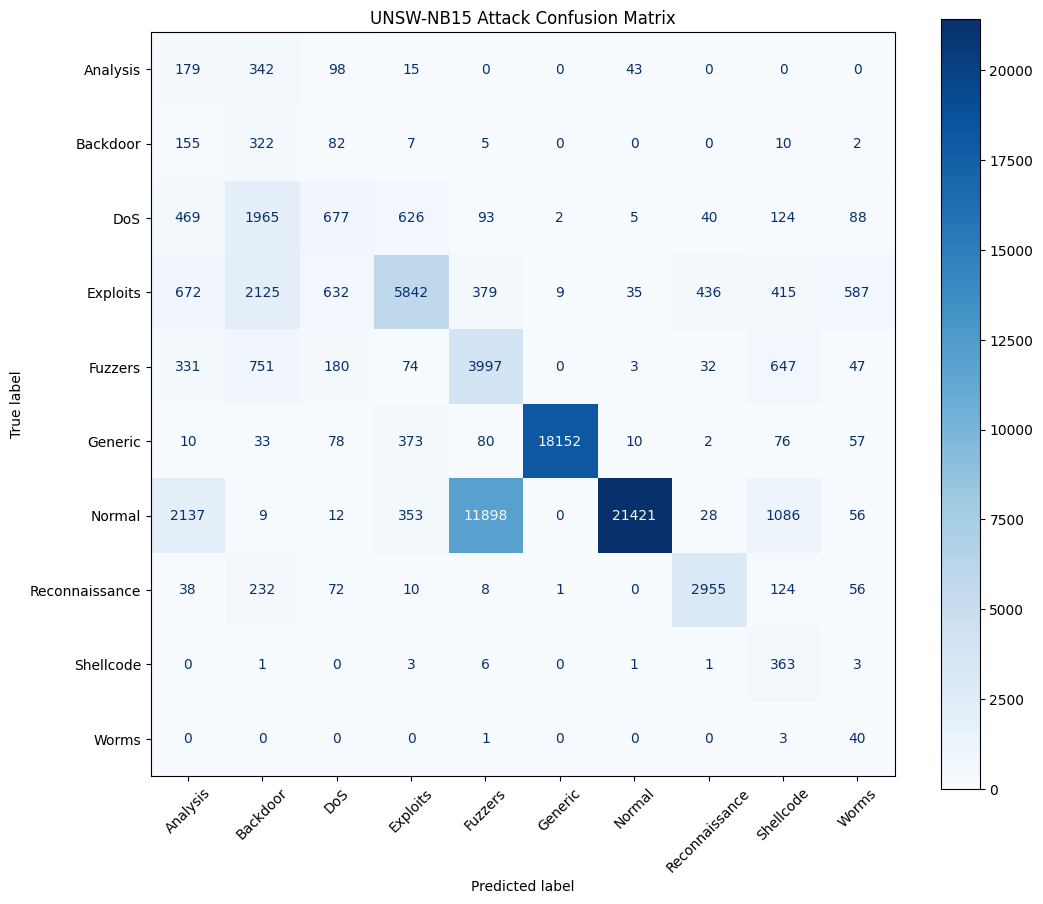

In [ ]:
# trying catboost
from catboost import CatBoostClassifier, Pool


for col in categorical_features:
    X_train_reduced[col] = X_train_reduced[col].astype(str).replace('nan', 'missing')
    X_test_reduced[col] = X_test_reduced[col].astype(str).replace('nan', 'missing')

X_subtrain, X_validation, y_subtrain, y_validation = train_test_split(X_train_reduced, y_train_final, test_size = 0.2, stratify= y_train_final, random_state = 42) # add stratify parameter because of imbalanced label samples

sub_weights = compute_sample_weight(class_weight = 'balanced', y=y_subtrain)

catbooster = CatBoostClassifier(
    iterations = 200, 
    learning_rate = .1,
    depth = 6,
    loss_function = 'MultiClass',
    eval_metric = 'TotalF1',
    random_seed = 42,
    verbose = 100,
    early_stopping_rounds=50,
    auto_class_weights = 'Balanced'
)

catbooster.fit(
    X_subtrain,
    y_subtrain,
    cat_features = categorical_features,
    eval_set = (X_validation, y_validation),
    use_best_model = True
)

y_predict_cat = catbooster.predict(X_test_reduced)


confmatrix = confusion_matrix(y_test_final, y_predict_cat)

# xgb.plot_importance(xgboost)

fig,ax = plt.subplots(figsize=(12,10))
disp = ConfusionMatrixDisplay(confusion_matrix=confmatrix, display_labels = le.classes_)
disp.plot(cmap = 'Blues', ax=ax, xticks_rotation=45)
plt.title('UNSW-NB15 Attack Confusion Matrix')
plt.show()




In [7]:
report = classification_report(y_test_final, y_predict_cat, target_names = le.classes_)
print(report)

                precision    recall  f1-score   support

      Analysis       0.04      0.26      0.08       677
      Backdoor       0.06      0.55      0.10       583
           DoS       0.37      0.17      0.23      4089
      Exploits       0.80      0.52      0.63     11132
       Fuzzers       0.24      0.66      0.35      6062
       Generic       1.00      0.96      0.98     18871
        Normal       1.00      0.58      0.73     37000
Reconnaissance       0.85      0.85      0.85      3496
     Shellcode       0.13      0.96      0.23       378
         Worms       0.04      0.91      0.08        44

      accuracy                           0.66     82332
     macro avg       0.45      0.64      0.43     82332
  weighted avg       0.86      0.66      0.72     82332



Self note but I think I am going with a more robust approach soon. First train a binary classification model, and if detects normal then return normal, else run the multi-class classification on ATTACKS only, aka remove the normal section from attack_cat label.

In [ ]:
#           Input Sample
#                 │
#                 ▼
#       Stage 1: Binary Model
#          Normal or Attack?
#             │
#    ┌────────┴────────┐
#    ▼                 ▼
# Normal         Stage 2 Model
#                     │
#                     ▼
#              Attack Category